In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
#Load dataset
df = pd.read_csv("customer prediction.csv")
df.head()

,age,income,will_buy
0,25,30000,0
1,35,40000,1
2,45,60000,1
3,30,35000,0
4,50,80000,1


In [ ]:
X = df[['age','income']]
y = df['will_buy']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
#Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
#Predict
y_pred = svm_model.predict(X_test)

In [ ]:
#Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Predictions:", y_pred)

Accuracy: 0.9655172413793104
Predictions: [1 1 0 0 1 1 0 0 0 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1]


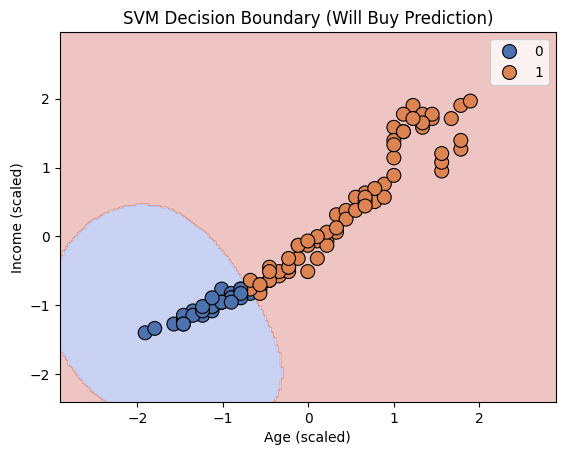

In [ ]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Create dataset
#Load dataset
df = pd.read_csv("customer prediction.csv")


X = df[["age", "income"]].values
y = df["will_buy"].values

# Scale features (important for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train SVM model (RBF kernel for non-linearity)
model = SVC(kernel="rbf", C=1, gamma="scale")
model.fit(X_scaled, y)

# Visualization of decision boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="deep", s=100, edgecolor="k")
    plt.xlabel("Age (scaled)")
    plt.ylabel("Income (scaled)")
    plt.title("SVM Decision Boundary (Will Buy Prediction)")
    plt.show()

plot_decision_boundary(X_scaled, y, model)
